<a href="https://colab.research.google.com/github/Montasir00/Ml_final_project/blob/tabby/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project**

Team members:
1. Pham Gia Khiem - 551026 (Vietnam)
2. Mohammed Hassan – 541140 (Bangladesh)
3. Fazlur Rahman - 541927 (Bangladesh)

# I. UNDERSTANDING THE DATASET

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('/content/final_project_dataset_complete.csv')
df

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0
...,...,...,...,...,...,...,...,...,...,...,...
8995,0.101630,0.400250,NaN,-0.019412,-0.063150,0.077627,0.540975,-0.169030,Above Average,Region A,0
8996,1.167218,2.177774,-1.716067,1.994835,0.350043,-0.544915,0.089050,-0.944220,High,Region C,1
8997,1.588447,3.333945,-2.615488,3.476880,-0.933276,2.027658,0.239583,1.951491,High,Region C,1
8998,-0.684987,-1.599835,1.063341,-1.252109,-0.724001,2.228943,0.989794,1.936476,Low,Region B,0


In [4]:
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   9000 non-null   float64
 1   feature_2   9000 non-null   float64
 2   feature_3   8600 non-null   float64
 3   feature_4   9000 non-null   float64
 4   feature_5   9000 non-null   float64
 5   feature_6   8500 non-null   float64
 6   feature_7   9000 non-null   float64
 7   feature_8   9000 non-null   float64
 8   category_1  9000 non-null   object 
 9   category_2  9000 non-null   object 
 10  target      9000 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 773.6+ KB


In [6]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,8600.000000,9000.000000,9000.000000,8500.000000,9000.000000,9000.000000,9000.000000
mean,0.000427,0.003349,0.003235,-0.008481,-0.002177,-0.006447,0.000592,0.003348,0.475444
std,1.241318,2.508324,1.542901,2.061784,0.577415,1.981615,1.075064,2.043643,0.499424
min,-18.665400,-37.852816,-6.676680,-8.190124,-0.999791,-8.590782,-4.422265,-9.474989,0.000000
25%,-0.680062,-1.382610,-1.022085,-1.399928,-0.502614,-1.329040,-0.700078,-1.356620,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.680513,1.380228,1.038571,1.394151,0.497004,1.324897,0.731942,1.402024,1.000000
max,21.934496,47.603454,6.203055,8.189001,0.999914,6.803751,3.857219,7.572578,1.000000


In [7]:
numerical_features = df.select_dtypes(include=['float64', 'int64'])

In [8]:
numerical_features.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0


In [9]:
numerical_corr = numerical_features.corr()

In [10]:
#correlation matrix
numerical_corr

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
feature_1,1.000000,0.995360,-0.831705,0.831922,-0.015305,-0.010813,-0.010843,-0.004581,0.605940
feature_2,0.995360,1.000000,-0.823242,0.832002,-0.014715,-0.011519,-0.011393,-0.005394,0.606016
feature_3,-0.831705,-0.823242,1.000000,-0.957222,0.011309,0.003989,0.006042,0.001846,-0.704351
feature_4,0.831922,0.832002,-0.957222,1.000000,-0.003613,-0.000213,-0.001369,0.001202,0.694885
feature_5,-0.015305,-0.014715,0.011309,-0.003613,1.000000,-0.009365,0.252371,-0.012717,-0.007873
feature_6,-0.010813,-0.011519,0.003989,-0.000213,-0.009365,1.000000,0.921569,0.969998,0.001457
feature_7,-0.010843,-0.011393,0.006042,-0.001369,0.252371,0.921569,1.000000,0.894220,-0.002000
feature_8,-0.004581,-0.005394,0.001846,0.001202,-0.012717,0.969998,0.894220,1.000000,0.004658
target,0.605940,0.606016,-0.704351,0.694885,-0.007873,0.001457,-0.002000,0.004658,1.000000


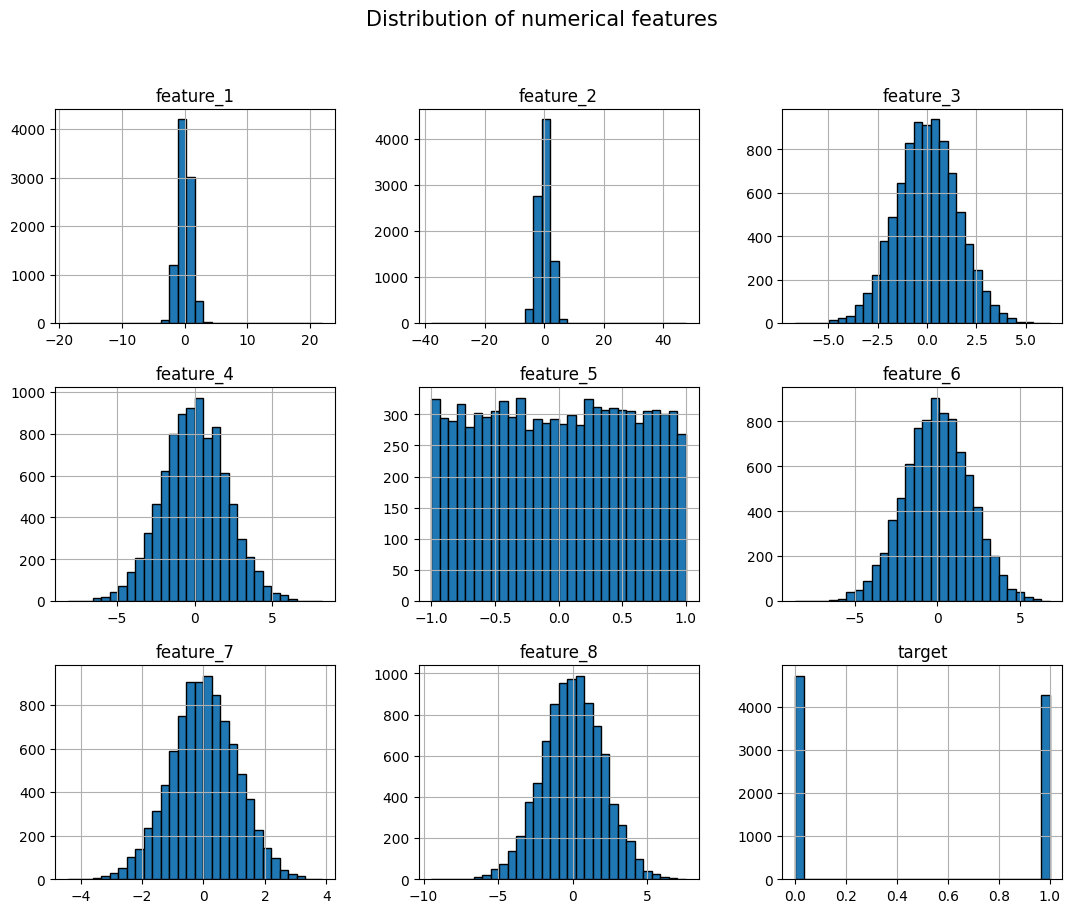

In [11]:
df.hist(bins = 30, figsize=(13,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

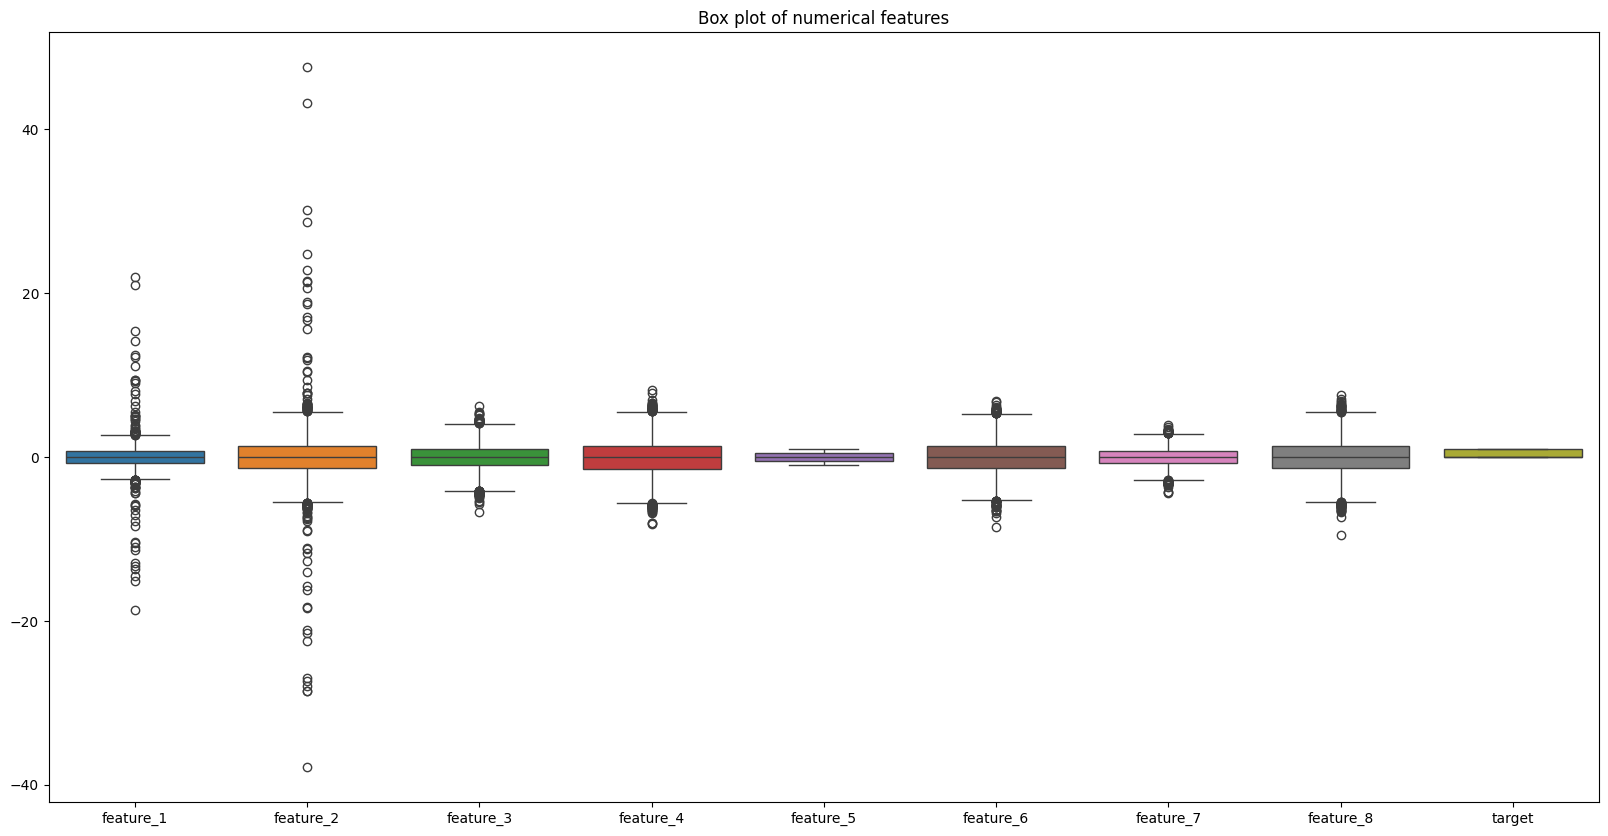

In [12]:
plt.figure(figsize=(20,10))
sns.boxplot(data=numerical_features)
plt.title('Box plot of numerical features')
plt.show()

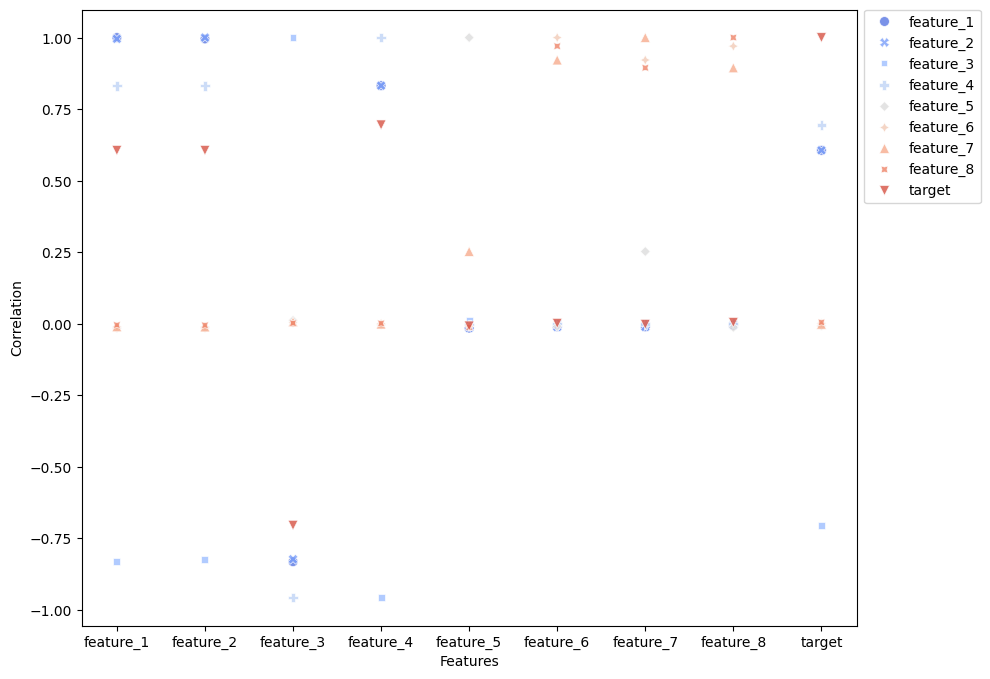

In [13]:
# Create a figure with specified size
fig, ax = plt.subplots(figsize=(10, 8))
# Visualizing the correlation between features and target using scatterplot
sns.scatterplot(data=numerical_corr, palette='coolwarm', alpha=0.8, s=50, ax=ax)

ax.set_xlabel('Features')
ax.set_ylabel('Correlation')

plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

# Show the plot
plt.show()

# II. DATA PREPROCESSING


In [15]:
df.isna().sum()

,0
feature_1,0
feature_2,0
feature_3,400
feature_4,0
feature_5,0
feature_6,500
feature_7,0
feature_8,0
category_1,0
category_2,0


In [16]:
missing_values = df.isna().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)

feature_3    400
feature_6    500
dtype: int64


In [17]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
df['feature_3'] = imputer.fit_transform(df[['feature_3']])
df['feature_6'] = imputer.fit_transform(df[['feature_6']])

In [18]:
df['feature_3'].isna().sum()
df['feature_6'].isna().sum()

0

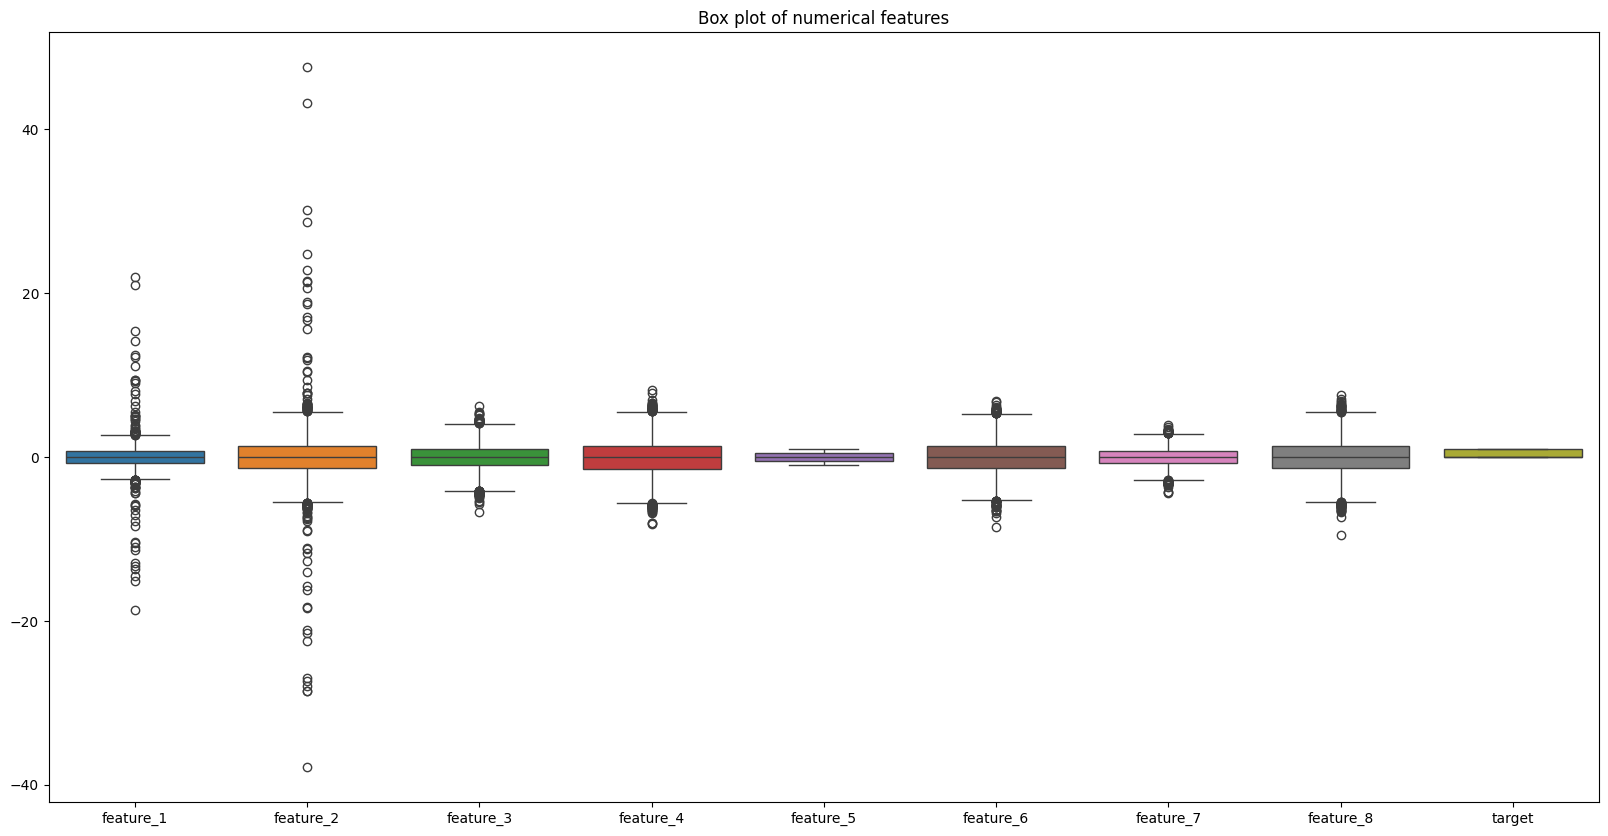

In [19]:
plt.figure(figsize=(20,10))
plt.title('Box plot of numerical features')
sns.boxplot(data=numerical_features)
plt.show()

In [20]:
def iqr_outliers(dataset, feature_name, multiplier= 1.5):
    # Calculate IQR
    Q1 = dataset[feature_name].quantile(0.25)
    Q3 = dataset[feature_name].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate limits
    lower_limit = Q1 - multiplier * IQR
    upper_limit = Q3 + multiplier * IQR

    # Identify outliers
    outliers = dataset[(dataset[feature_name] < lower_limit) | (dataset[feature_name] > upper_limit)]

    return outliers, {'lower_limit': lower_limit, 'upper_limit': upper_limit}

outliers_detected = {}

for feature in numerical_features.columns:
    outliers, limits = iqr_outliers(numerical_features, feature)
    outliers_detected[feature] = {
        'count': len(outliers),
        'indices': outliers.index.tolist(),
        'limits': limits
    }

    print(f'Feature: {feature}')
    print(f'Number of outliers: {len(outliers)}')
    print(f'Lower limit: {limits["lower_limit"]}, Upper limit: {limits["upper_limit"]}')
    print(f'Outlier indices: {outliers.index.tolist()}')
    print('-' * 50)

Feature: feature_1
Number of outliers: 113
Lower limit: -2.7209235765, Upper limit: 2.7213741995
Outlier indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Number of outliers: 106
Lower limit: -5.5268680488749995, Upper limit: 5.524485932125
Outlier indices: [209, 262, 277, 469, 478, 496, 598, 774, 1

In [21]:
df_1 = df.copy()
for feature, values in outliers_detected.items():
    outlier_indices = values['indices']
    # calculate the median value
    median_value = df_1[feature].median()
    # replace outliers with median values
    df_1.loc[outlier_indices, feature] = median_value

    print(f"Feature: {feature}")
    print(f"Replaced outliers in indices: {outlier_indices}")
    print('-' * 50)

Feature: feature_1
Replaced outliers in indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1539, 1591, 1615, 1785, 1957, 1971, 2024, 2035, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2521, 2884, 2895, 2947, 3017, 3152, 3227, 3241, 3245, 3336, 3454, 3510, 3569, 3716, 3872, 3982, 3986, 4026, 4029, 4033, 4047, 4091, 4198, 4207, 4265, 4359, 4531, 4617, 4635, 4639, 4725, 4779, 4784, 4870, 4997, 5157, 5224, 5316, 5416, 5488, 5587, 5642, 5649, 5673, 5773, 5796, 5846, 5907, 5935, 5998, 6350, 6408, 6628, 6693, 6738, 6747, 6891, 7060, 7140, 7178, 7223, 7290, 7305, 7330, 7441, 7498, 7611, 7624, 7677, 7839, 7851, 7858, 7872, 7874, 8024, 8067, 8165, 8180, 8200, 8248, 8283, 8354, 8630, 8714, 8726]
--------------------------------------------------
Feature: feature_2
Replaced outliers in indices: [209, 262, 277, 469, 478, 496, 598, 774, 1061, 1101, 1400, 1445, 1591, 1615, 1785, 1957, 1971, 2024, 2093, 2218, 2228, 2305, 2336, 2442, 2458, 2506, 2895, 2947, 3017, 3152, 3227, 3

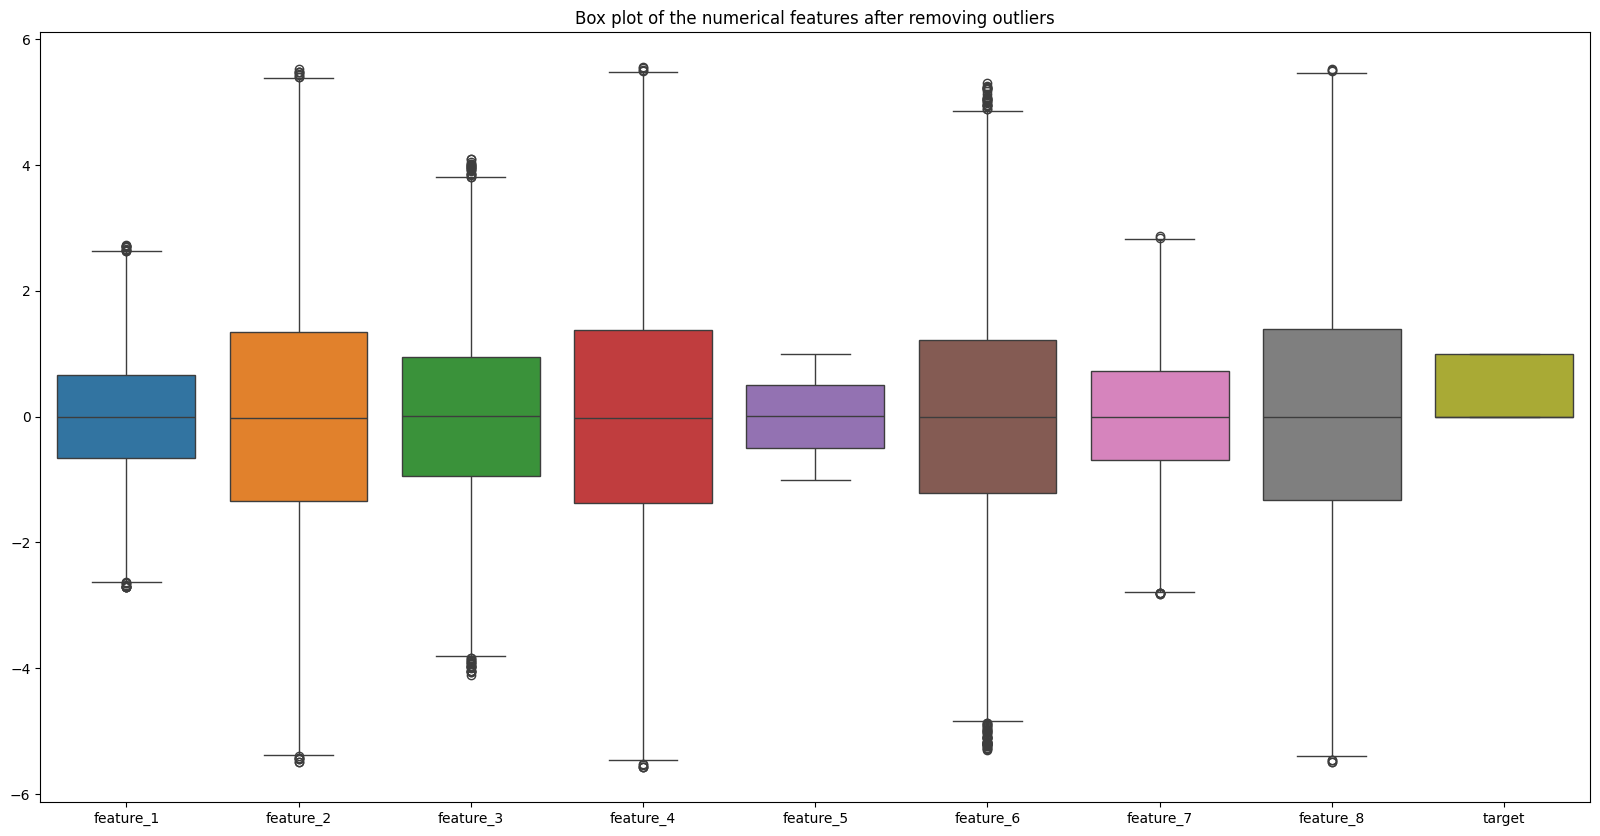

In [22]:
plt.figure(figsize=(20, 10))
plt.title('Box plot of the numerical features after removing outliers')
sns.boxplot(data=df_1)
plt.show()

In [23]:
df_1.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005988,-0.010226,-0.002177,0.004222,0.006010,0.010578,0.475444
std,0.971927,1.959564,1.429225,1.986669,0.577415,1.818435,1.038181,1.980097,0.499424
min,-2.712613,-5.486925,-3.881410,-5.569645,-0.999791,-4.936580,-2.819977,-5.490152,0.000000
25%,-0.657194,-1.346706,-0.939994,-1.377240,-0.502614,-1.186692,-0.684357,-1.329677,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.659561,1.343450,0.941969,1.368650,0.497004,1.202089,0.720851,1.386503,1.000000
max,2.720169,5.516173,3.854354,5.552331,0.999914,4.950231,2.876070,5.529430,1.000000


In [23]:
#label encoding
category_columns = df_1[['category_1', 'category_2']]
for column in category_columns:
    unique_values = df_1[column].unique()
    unique_count = df_1[column].nunique()

    print(f"Column '{column}':")
    print(f"Unique values: {unique_values}")
    print(f"Number of unique options: {unique_count}")
    print('-' * 30)

Column 'category_1':
Unique values: ['Above Average' 'Below Average' 'High' 'Low']
Number of unique options: 4
------------------------------
Column 'category_2':
Unique values: ['Region C' 'Region A' 'Region B']
Number of unique options: 3
------------------------------


In [24]:
# Making a copy of the dataset to avoid changing the original data
df_2 = df_1.copy()
label_encoder = LabelEncoder()
label_encoder = LabelEncoder()
df_2['cat_1_encoded'] = label_encoder.fit_transform(df_2['category_1'])
# One-Hot Encoding for category_2 (nominal)
df_one_hot = pd.get_dummies(df_2['category_2'])

# Combine the original dataframe with the one-hot encoded dataframe
df_2 = pd.concat([df_2, df_one_hot], axis=1)

# Drop the original category_2 column if no longer needed
df_2.drop(columns=['category_1', 'category_2'], inplace=True)

# Display the final dataframe
df_2.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,cat_1_encoded,Region A,Region B,Region C
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,1,0,False,False,True
1,-0.138264,-0.061846,0.005196,0.403768,0.704674,-2.498565,-1.339227,-1.942298,0,1,True,False,False
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,1,2,False,False,True
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,1,2,False,True,False
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,0,1,False,False,True


In [25]:
print(f'Before changing column names:\n {df_2.columns}')

# Renaming columns
df_2.rename(columns={
    'Region A': 'region_A',
    'Region B': 'region_B',
    'Region C': 'region_C'
}, inplace=True)

# Verify column names
print(f'After changing column names:\n {df_2.columns}')

Before changing column names:
 Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'target', 'cat_1_encoded',
       'Region A', 'Region B', 'Region C'],
      dtype='object')
After changing column names:
 Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5',
       'feature_6', 'feature_7', 'feature_8', 'target', 'cat_1_encoded',
       'region_A', 'region_B', 'region_C'],
      dtype='object')


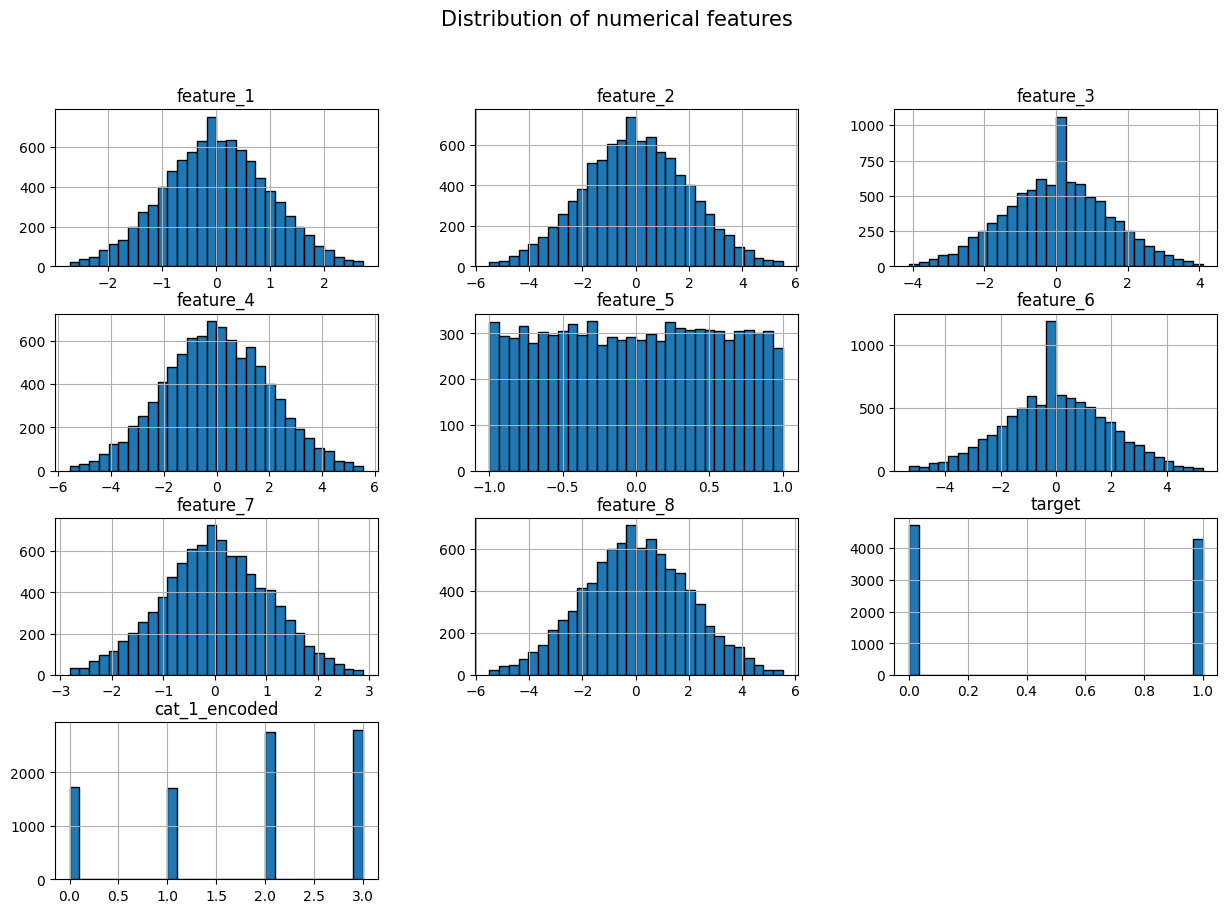

In [26]:
df_2.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.suptitle("Distribution of numerical features", fontsize = 15)
plt.show()

In [28]:
df_2.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target,cat_1_encoded
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,-0.000672,0.002354,0.005962,-0.010226,-0.002177,-0.004937,0.006010,0.010578,0.475444,1.737778
std,0.971927,1.959564,1.448882,1.986669,0.577415,1.865959,1.038181,1.980097,0.499424,1.095463
min,-2.712613,-5.486925,-4.104379,-5.569645,-0.999791,-5.299373,-2.819977,-5.490152,0.000000,0.000000
25%,-0.657194,-1.346706,-0.950363,-1.377240,-0.502614,-1.211517,-0.684357,-1.329677,0.000000,1.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000,2.000000
75%,0.659561,1.343450,0.954145,1.368650,0.497004,1.218900,0.720851,1.386503,1.000000,3.000000
max,2.720169,5.516173,4.096764,5.552331,0.999914,5.293819,2.876070,5.529430,1.000000,3.000000


In [29]:
# export cleaned dataset
df_2.to_csv('C:\depression analysis\Machine Learning\final project\cleaned_dataset.csv')

# III. EDA (EXPLORATORY DATA ANALYSIS)




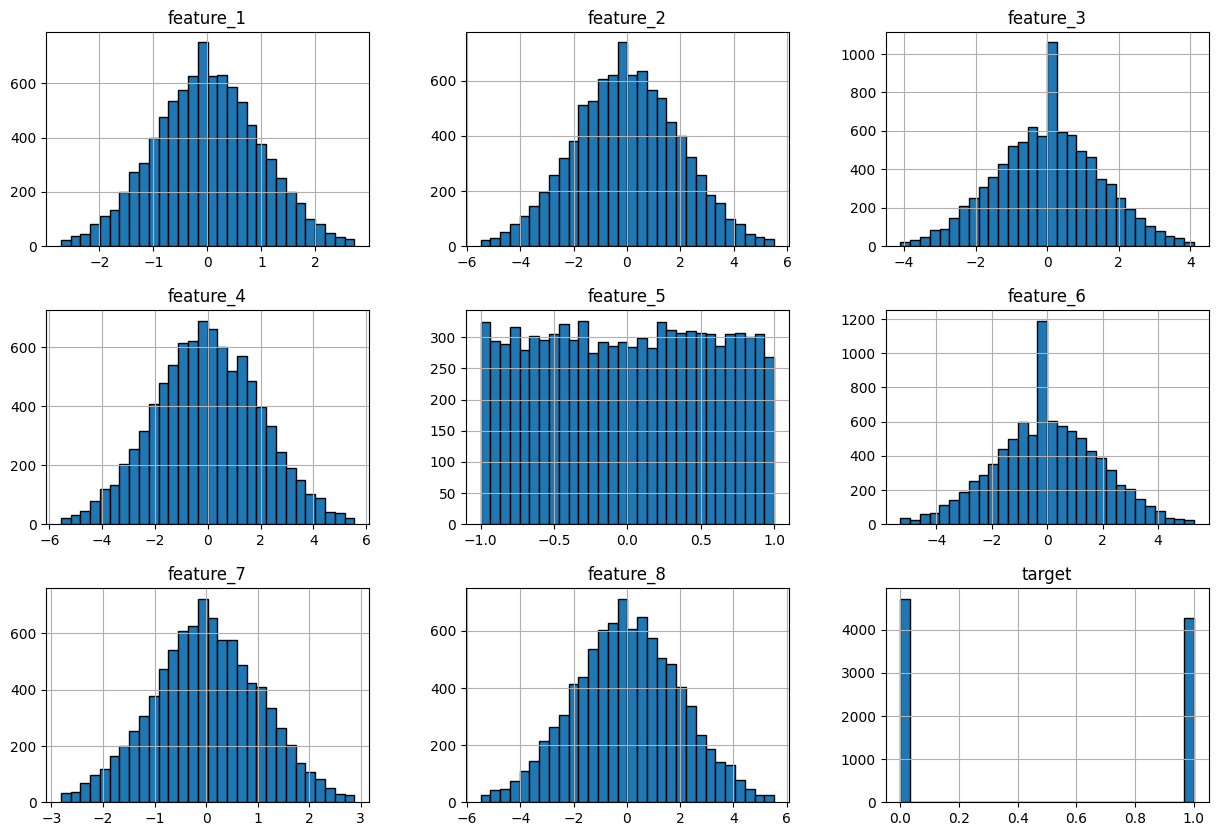

In [30]:
df_1.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.show()

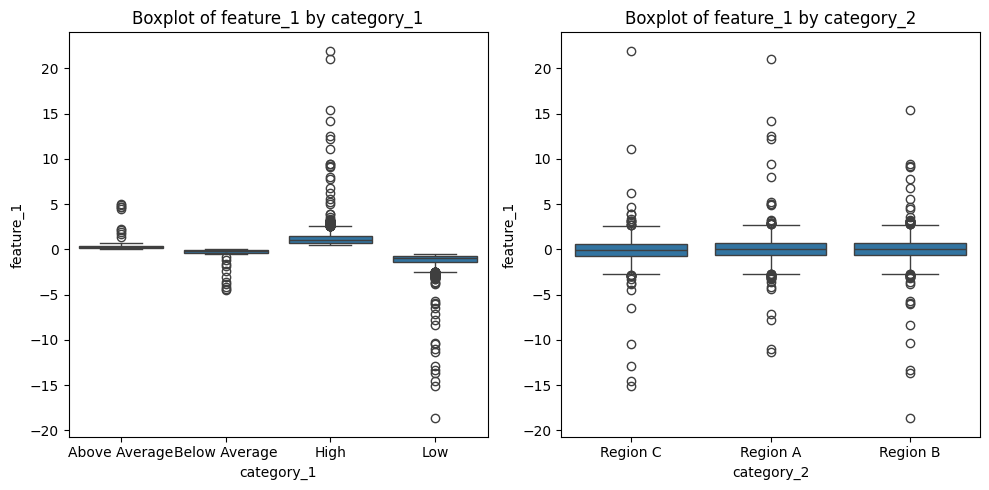

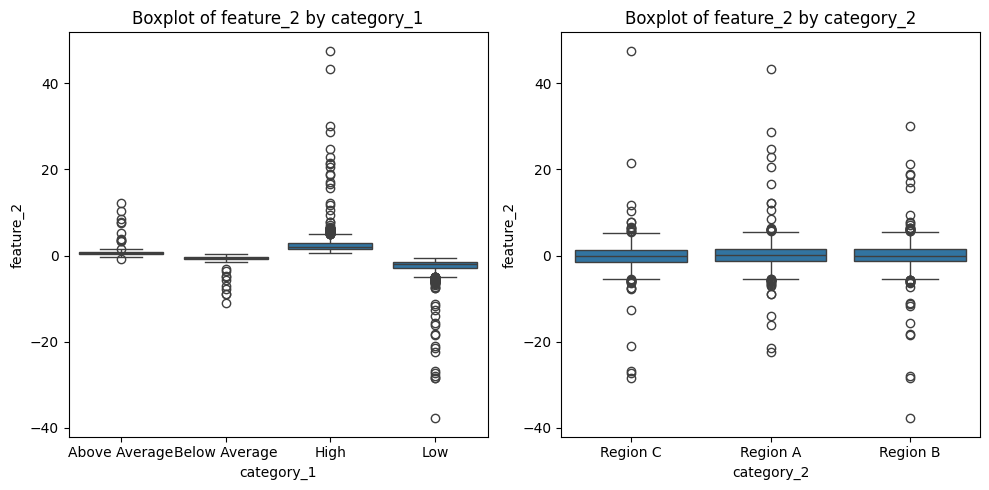

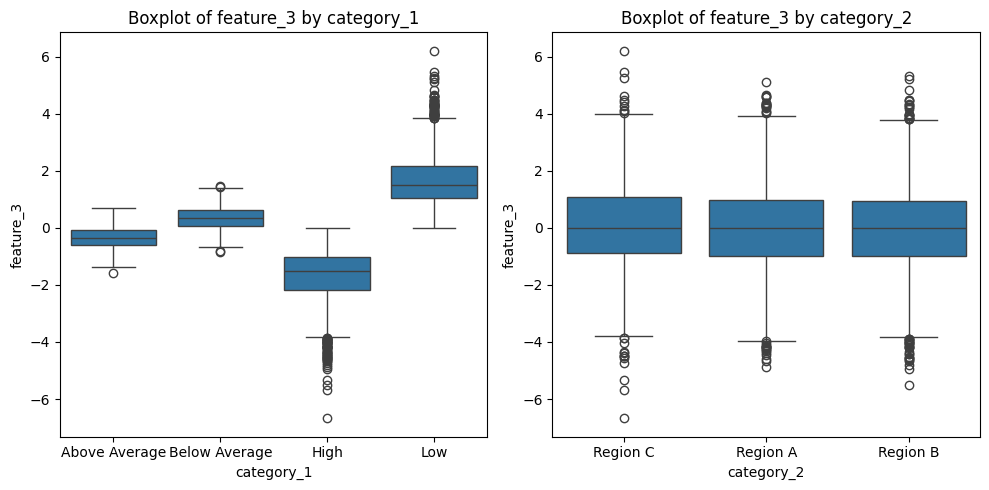

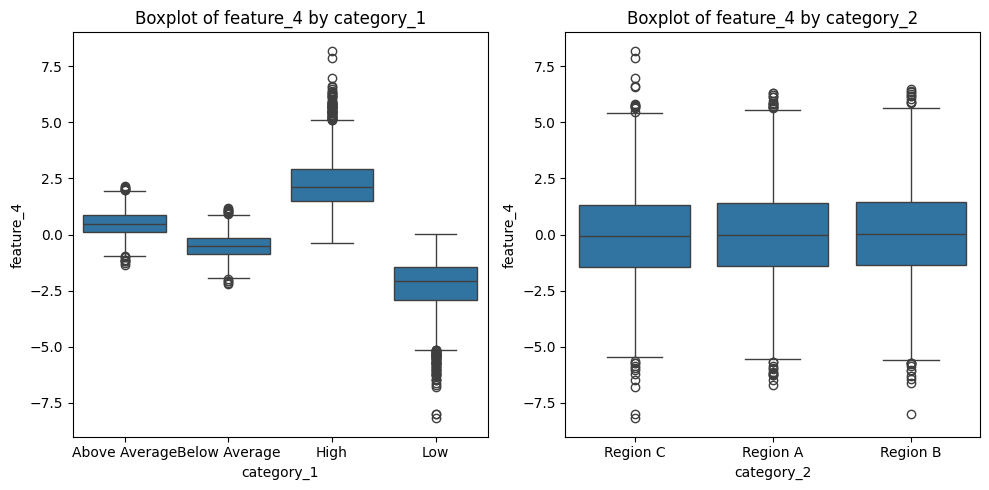

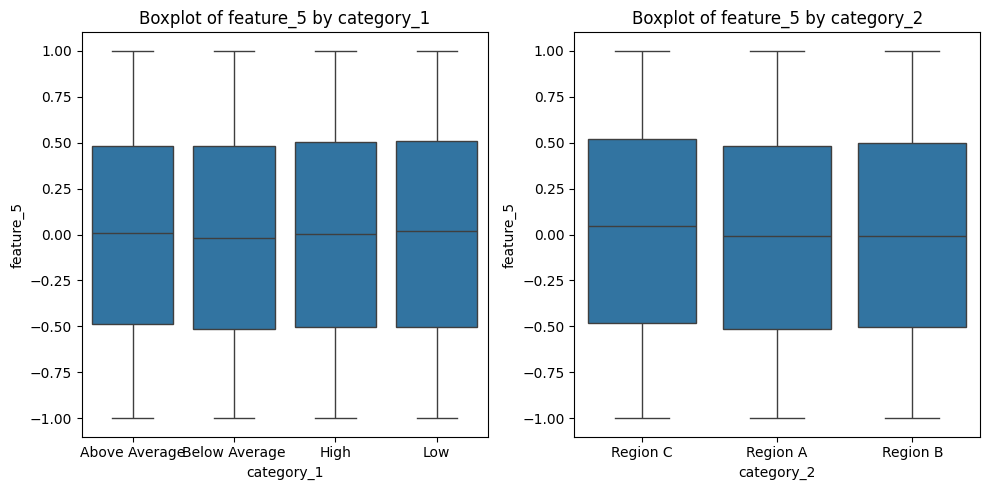

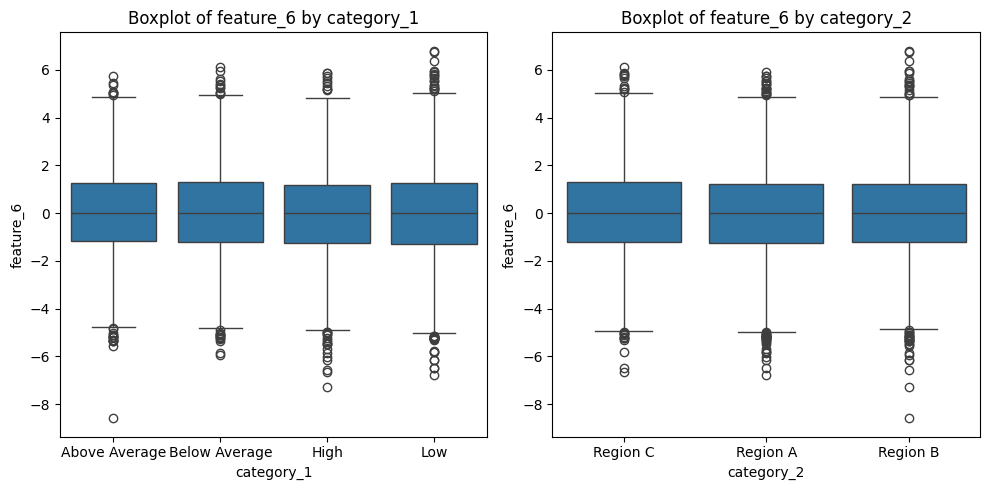

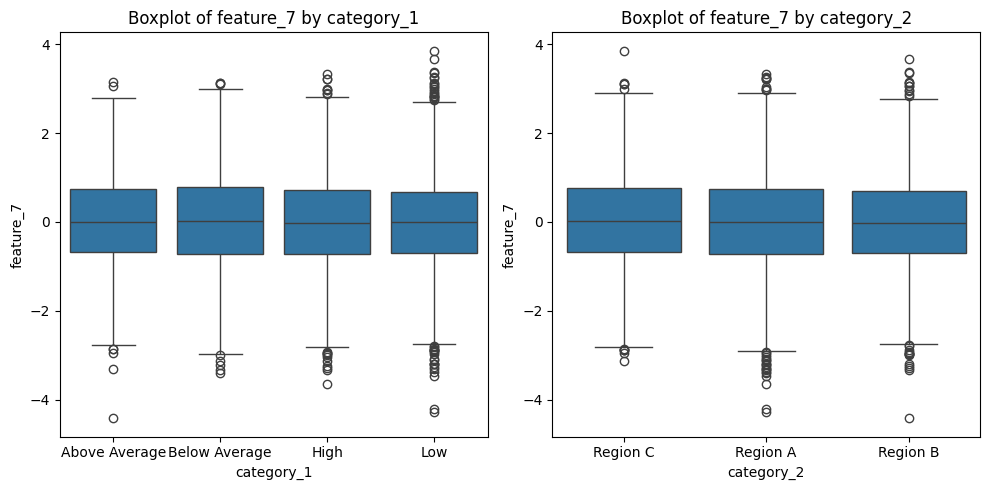

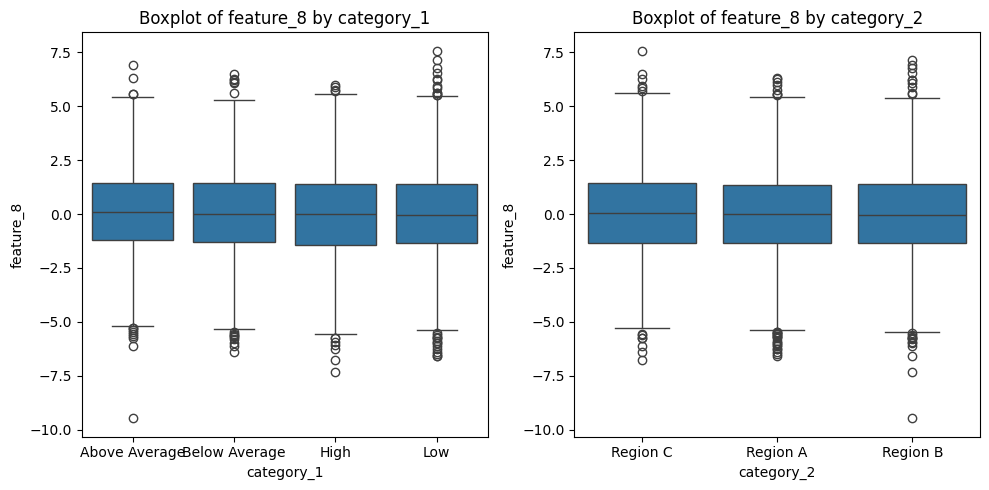

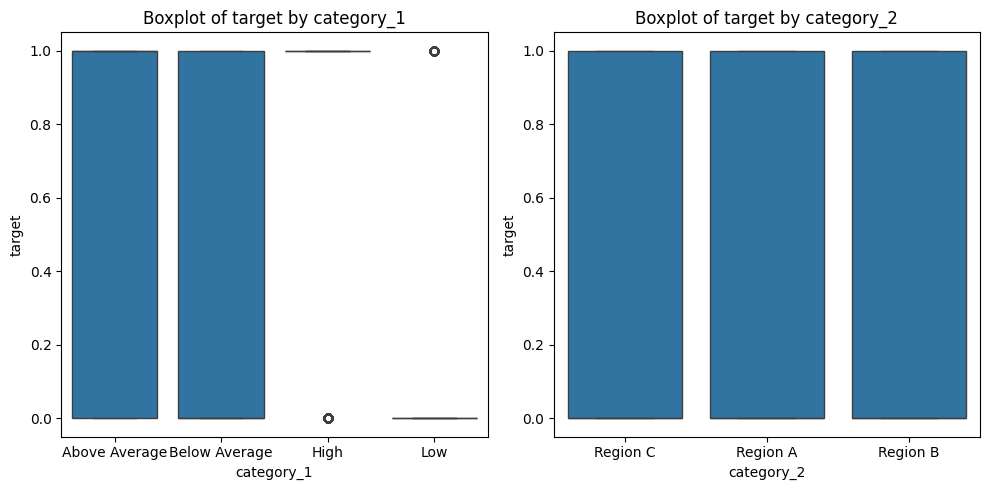

In [31]:
for column in numerical_features:
    plt.figure(figsize=(10, 5))

    # Boxplot by category_1
    plt.subplot(1, 2, 1)  # Creates 1 row and 2 columns of subplots, and the first one is selected
    sns.boxplot(x='category_1', y=column, data=df)
    plt.title(f'Boxplot of {column} by category_1')

    # Boxplot by category_2
    plt.subplot(1, 2, 2)  # Select the second subplot
    sns.boxplot(x='category_2', y=column, data=df)
    plt.title(f'Boxplot of {column} by category_2')

    plt.tight_layout()  # Adjust the layout for better spacing
    plt.show()

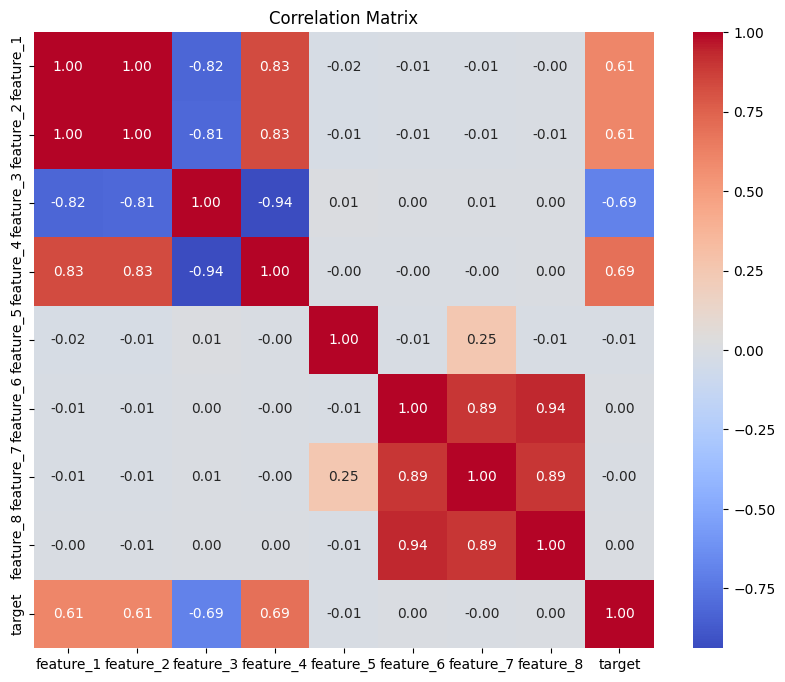

In [57]:
# plot heatmap that visualize the correlation matrix
correlation_matrix = numerical_features.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [32]:
# perform t-tests
results = {}
for feature in numerical_features[:-1]:
    group1 = df[df['target'] == 1][feature].dropna()
    group0 = df[df['target'] == 0][feature].dropna()
    t_stat, p_value = stats.ttest_ind(group1, group0)
    results[feature] = {'t_statistic': t_stat, 'p_value': p_value}
results_df = pd.DataFrame(results).T
results_df.index.name = 'Feature'
print(results_df)

           t_statistic   p_value
Feature                         
feature_1    72.253084  0.000000
feature_2    72.267409  0.000000
feature_3   -90.276861  0.000000
feature_4    91.660903  0.000000
feature_5    -0.746804  0.455201
feature_6     0.134524  0.892991
feature_7    -0.189743  0.849515
feature_8     0.441833  0.658621
target             inf  0.000000


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [33]:
# perform chi-square tests
chi_square_results = {}

contingency_table_1 = pd.crosstab(df['category_1'], df['target'])
chi2_stat_1, p_value_1, dof_1, expected_1 = stats.chi2_contingency(contingency_table_1)
chi_square_results['category_1'] = {'chi2_statistic': chi2_stat_1, 'p_value': p_value_1}

contingency_table_2 = pd.crosstab(df['category_2'], df['target'])
chi2_stat_2, p_value_2, dof_2, expected_2 = stats.chi2_contingency(contingency_table_2)
chi_square_results['category_2'] = {'chi2_statistic': chi2_stat_2, 'p_value': p_value_2}

chi_square_results_df = pd.DataFrame.from_dict(chi_square_results, orient='index')
chi_square_results_df.index.name = 'Category'

print(chi_square_results_df)

            chi2_statistic  p_value
Category                           
category_1     5175.320287  0.00000
category_2        1.319349  0.51702


# IV. FEATURE ENGINEERING

In [36]:
df_3 = df_2.copy()

# Function to engineer new features
def feature_engineering(df_3):
    # Drop unnecessary features
    df_3 = df_3.drop(['feature_7', 'feature_8', 'feature_5'], axis=1)

    # Create a new feature based on existing ones
    df_3['feature_9'] = df_3['feature_1'] * df_3['feature_4']

    return df_3

# Apply feature engineering
df_3 = feature_engineering(df_3)

# Display the first few rows of the modified DataFrame
df_3.head()

,feature_1,feature_2,feature_3,feature_4,feature_6,target,cat_1_encoded,region_A,region_B,region_C,feature_9
0,0.496714,1.146509,-0.648521,0.833005,-2.209437,1,0,False,False,True,0.413765
1,-0.138264,-0.061846,0.005196,0.403768,-2.498565,0,1,True,False,False,-0.055827
2,0.647689,1.395115,-0.764126,1.708266,1.956259,1,2,False,False,True,1.106424
3,1.523030,2.657560,-2.461653,2.649051,3.445638,1,2,False,True,False,4.034584
4,-0.234153,-0.499391,0.576097,-0.441656,0.211425,0,1,False,False,True,0.103415


In [37]:
df_4 = df_3.copy()

scaler = MinMaxScaler()

# Loop through each numerical feature and apply MinMax scaling
for feature in df_4:
    df_4[feature] = scaler.fit_transform(df_4[[feature]])

# Display the first few rows of the normalized dataset
print(df_4.head())

   feature_1  feature_2  feature_3  feature_4  feature_6  target  \
0   0.590734   0.602870   0.421387   0.575676   0.291691     1.0   
1   0.473855   0.493050   0.501098   0.537082   0.264397     0.0   
2   0.618523   0.625464   0.407291   0.654372   0.684934     1.0   
3   0.779645   0.740199   0.200304   0.738960   0.825531     1.0   
4   0.456204   0.453284   0.570710   0.461068   0.520221     0.0   

   cat_1_encoded  region_A  region_B  region_C  feature_9  
0       0.000000       0.0       0.0       1.0   0.091154  
1       0.333333       1.0       0.0       0.0   0.061612  
2       0.666667       0.0       0.0       1.0   0.134728  
3       0.666667       0.0       1.0       0.0   0.318937  
4       0.333333       0.0       0.0       1.0   0.071630  


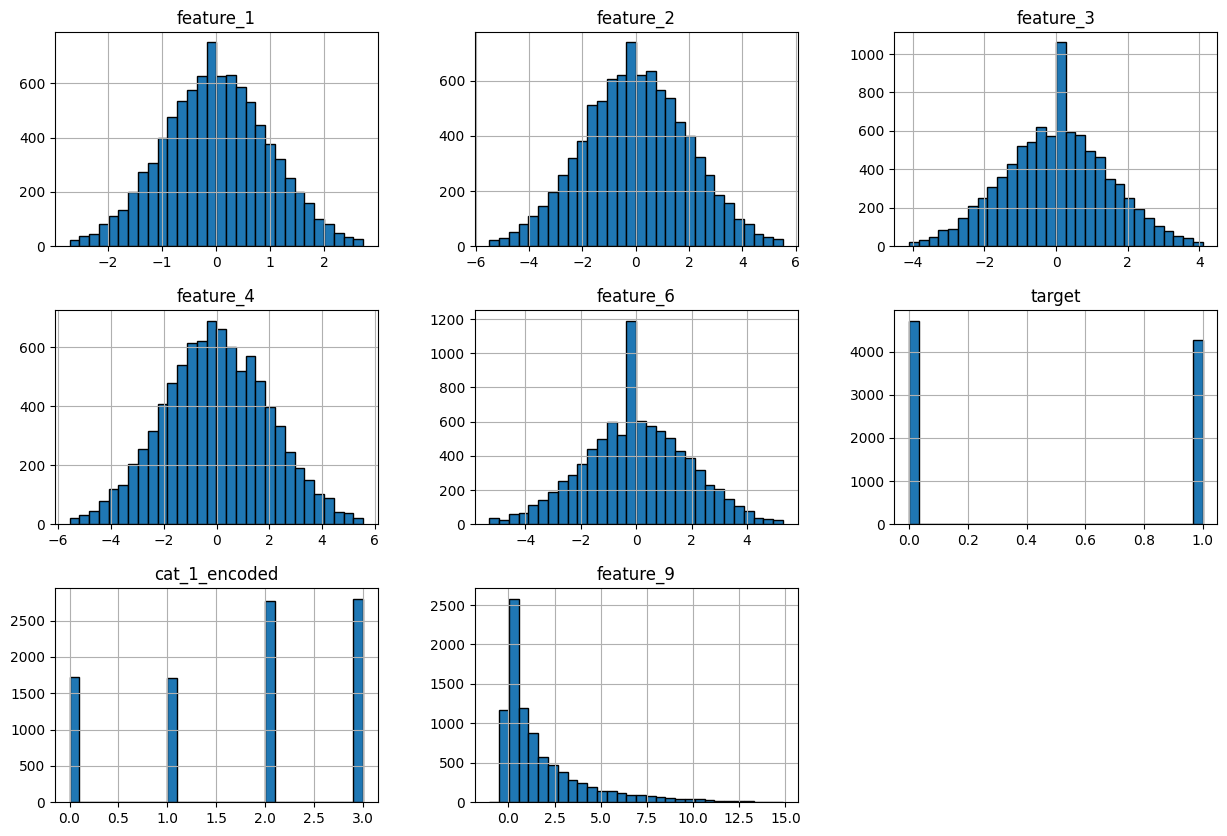

In [38]:
df_3.hist(bins = 30, figsize=(15,10), edgecolor = 'black')
plt.show()

# V. **MODELING**

In [39]:
X = df_4.drop('target', axis=1)
y = df_4['target']

In [40]:
def select_features(X, y):
    model = RandomForestClassifier(random_state=42)
    rfe = RFE(model, n_features_to_select=10)
    X_final = rfe.fit_transform(X, y)
    final_features = X.columns[rfe.get_support()]
    print(final_features)
    return final_features

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [42]:
selected_features = select_features(X_train, y_train)
X_test = X_test[selected_features]
X_train = X_train[selected_features]

print(len(X_train))
print(len(X_test))

Index(['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_6',
       'cat_1_encoded', 'region_A', 'region_B', 'region_C', 'feature_9'],
      dtype='object')
7200
1800


In [43]:
def evaluate_model(model, param_grid, X_train, y_train, X_test, y_test):
    # GridSearchCV for hyperparameter tuning
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    # Training the model with the best parameters
    best_model = grid_search.best_estimator_

    # Predictions
    predictions = best_model.predict(X_test)

    # Best parameters
    best_parameters = grid_search.best_params_
    print("Best Parameters:", best_parameters)

    print("Classification Report:")
    print(classification_report(y_test, predictions))

    # Evaluation
    conf_matrix = confusion_matrix(y_test, predictions)

    # Visualization of Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.DataFrame(conf_matrix), annot=True, cmap="YlGnBu", fmt='g')
    plt.title('Confusion matrix')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()

    return best_model

In [44]:
# Check overfitting
def check_overfitting(model, X_train, y_train, X_test, y_test):
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Testing Accuracy: {test_accuracy:.4f}")

In [45]:
def feature_importance(model, selected_features):
    # Feature importances from Best Random Forest
    importances = model.feature_importances_
    feature_names = X[selected_features].columns
    feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    print(feature_importance_df.sort_values(by='importance', ascending=False))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.90      0.89       947
         1.0       0.89      0.85      0.87       853

    accuracy                           0.88      1800
   macro avg       0.88      0.88      0.88      1800
weighted avg       0.88      0.88      0.88      1800



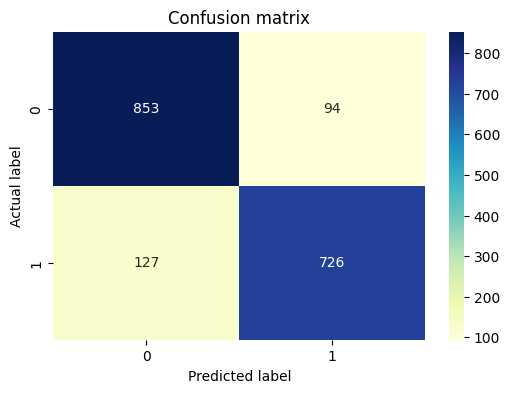

Training Accuracy: 0.9217
Testing Accuracy: 0.8772
         feature  importance
1      feature_2    0.351518
2      feature_3    0.244714
0      feature_1    0.210907
3      feature_4    0.075402
5  cat_1_encoded    0.048322
9      feature_9    0.044111
4      feature_6    0.019162
6       region_A    0.002315
8       region_C    0.001860
7       region_B    0.001690


In [46]:
# Example usage for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf = evaluate_model(RandomForestClassifier(random_state=42), rf_param_grid, X_train, y_train, X_test, y_test)
check_overfitting(rf, X_train, y_train, X_test, y_test)
feature_importance(rf, selected_features)

In [71]:
# default Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

y_train_pred = rf_default.predict(X_train)

y_test_pred = rf_default.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 0.9998611111111111
Testing Accuracy: 0.8755555555555555


In [69]:
# default SVM
svm_default = SVC(random_state=42)
svm_default.fit(X_train, y_train)
svm_default_predictions = svm_default.predict(X_test)

y_train_pred = svm_default.predict(X_train)

y_test_pred = svm_default.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 0.8544444444444445
Testing Accuracy: 0.8583333333333333


Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.87      0.87       947
         1.0       0.86      0.86      0.86       853

    accuracy                           0.87      1800
   macro avg       0.87      0.87      0.87      1800
weighted avg       0.87      0.87      0.87      1800



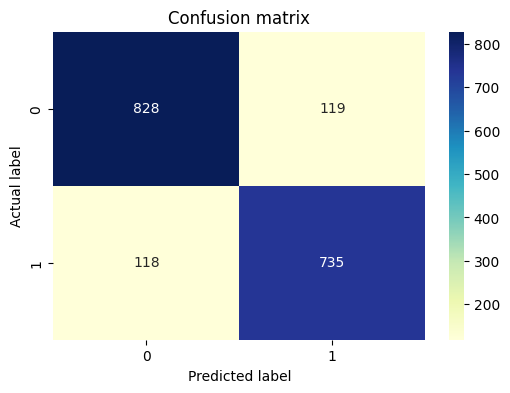

Training Accuracy: 0.8700
Testing Accuracy: 0.8683


In [61]:
# SVM with tunning
svm_param_grid = {
    'C': [0.1, 1, 10],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel function
    'gamma': ['scale', 'auto',],  # Kernel coefficient for 'rbf', 'poly'
}
svm = evaluate_model(SVC(random_state=42),svm_param_grid,X_train,y_train,X_test,y_test)
check_overfitting(svm, X_train, y_train, X_test, y_test)

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.86      0.86       947
         1.0       0.84      0.84      0.84       853

    accuracy                           0.85      1800
   macro avg       0.85      0.85      0.85      1800
weighted avg       0.85      0.85      0.85      1800



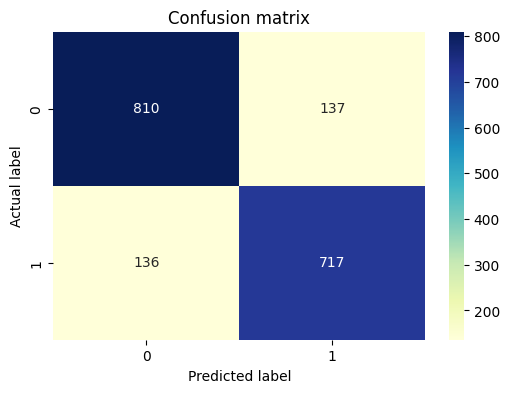

Training Accuracy: 0.8546
Testing Accuracy: 0.8483


In [ ]:
# Example usage for Logistic Regression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
lr = evaluate_model(LogisticRegression(random_state=42, max_iter=1000), lr_param_grid, X_train, y_train, X_test, y_test)
check_overfitting(lr, X_train, y_train, X_test, y_test)

In [72]:
# default Logistic Regression
lr_default = LogisticRegression(random_state=42)
lr_default.fit(X_train, y_train)

y_train_pred = lr_default.predict(X_train)

y_test_pred = lr_default.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 0.8552777777777778
Testing Accuracy: 0.8555555555555555


Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.92      0.87       947
         1.0       0.90      0.80      0.84       853

    accuracy                           0.86      1800
   macro avg       0.87      0.86      0.86      1800
weighted avg       0.86      0.86      0.86      1800



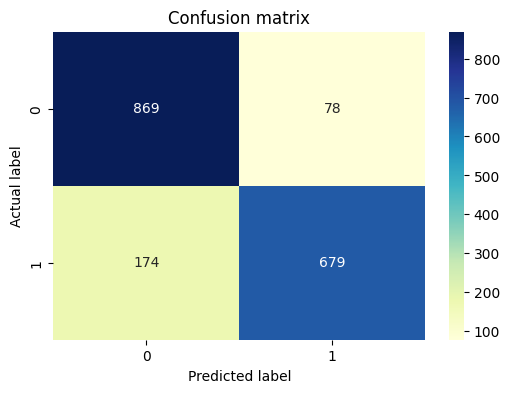

Training Accuracy: 0.9135
Testing Accuracy: 0.8600
         feature  importance
1      feature_2    0.710651
2      feature_3    0.152511
0      feature_1    0.043759
3      feature_4    0.032513
4      feature_6    0.025296
9      feature_9    0.020778
5  cat_1_encoded    0.010860
8       region_C    0.001884
6       region_A    0.001748
7       region_B    0.000000


In [53]:
# Example usage for Decision Tree
dt_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
}
dt = evaluate_model(DecisionTreeClassifier(random_state=42), dt_param_grid, X_train, y_train, X_test, y_test)
check_overfitting(dt, X_train, y_train, X_test, y_test)
feature_importance(dt, selected_features)

In [73]:
# default Decision Tree
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

y_train_pred = dt_default.predict(X_train)

y_test_pred = dt_default.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

Training Accuracy: 1.0
Testing Accuracy: 0.8272222222222222
